In [1]:
import sys
sys.path.append('../../')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance)
from run import initialize,train,test
from src.IO import ExperimentLogger

In [17]:
n_units_list = [500]#, 10, 15, 20, 30, 50]
k_sub = 5
n_families = 10
N_train = 2**5
n_units = 5

CONF = {
    # environment
        # energies
    "n_families": n_families,
    "latent_dim": 10,
        # concentration
    "init_means": [np.random.randint(1, 8) for _ in range(n_families)], # Fixed 
    "shape_sigma": 1./n_families,
    # receptor 
    "k_sub": k_sub, # number of sub-units
    "temperature": .1, # temperature of the sigmoid that approximate a binary answer
    "n_units" : n_units, # number of genes
    "receptor_indices" : torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long), # actual receptors considered
    
    # training characteristics
    "batch_size": N_train,
    "epochs": 5000,


    "lr": 0.05, # learning rate
    "exact_loss": True, # type of loss
    "use_scheduler":False
    
}

In [18]:
for n_units in n_units_list:
    print(f"\n--- Starting training for n_units = {n_units} ---")
    
    CONF["n_units"] = n_units
    CONF["receptor_indices"] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)], dtype=torch.long)

    env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
    
    print(env.base_energy_u)

    train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])


--- Starting training for n_units = 500 ---
Parameter containing:
tensor([8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.0590,
        8.0590, 8.0590, 8.0590, 8.0590, 8.0590, 8.059

OutOfMemoryError: CUDA out of memory. Tried to allocate 954.00 MiB. GPU 0 has a total capacity of 3.63 GiB of which 99.62 MiB is free. Including non-PyTorch memory, this process has 2.92 GiB memory in use. Of the allocated memory 2.26 GiB is allocated by PyTorch, and 598.19 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

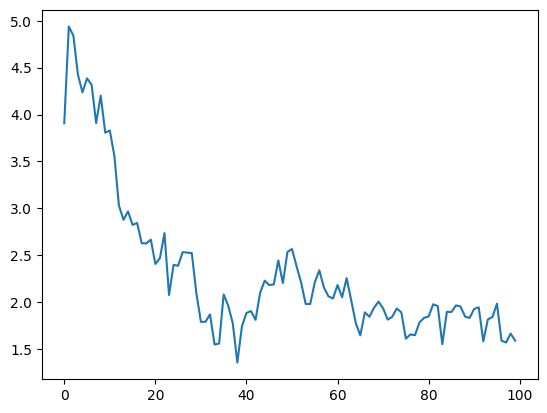

In [12]:
plt.plot(train_out['full_array_entropy'])

In [8]:
print(env.base_energy_u)

print(env.unit_latent)

Parameter containing:
tensor([ 8.8937,  7.6380,  0.5943,  7.9449,  2.8570,  7.2749,  8.8599, 10.1983,
        10.6414, 11.2644, 10.5207, 11.1731,  6.4502, 11.0401, 10.6862,  7.3833,
         6.0932,  7.7002,  8.9479,  9.7343,  9.6155, 10.6288,  8.7210,  9.3715,
        10.8930, 11.5015, 10.7345, 10.8554,  3.9820,  7.5195, 10.6353,  4.7077,
        10.5061,  9.9259,  9.5507,  8.2656,  9.3282, 10.9086, 10.8941, 10.7890,
         7.2761, 10.5399,  8.9996, 11.5939,  9.8957,  9.6822,  8.1382,  5.8330,
         7.8056,  9.5299], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[-0.2979, -0.5802, -1.0688, -0.5372,  2.6474, -1.6915, -1.6995,  1.9639,
          3.6476, -2.8704],
        [-3.3719,  0.1426,  1.3217, -0.3090, -1.5372,  3.3603, -0.8643, -1.8554,
          0.5999,  3.0326],
        [ 0.0314, -0.6225, -0.8606, -0.3497,  0.8791,  0.4078, -1.3687,  0.7816,
         -0.4408, -1.2417],
        [-3.2016,  0.1959,  2.0086, -2.0529,  2.3475, -1.2143,  1.4525, -0.2854,
    

Fitting UMAP... (This may take a few seconds)


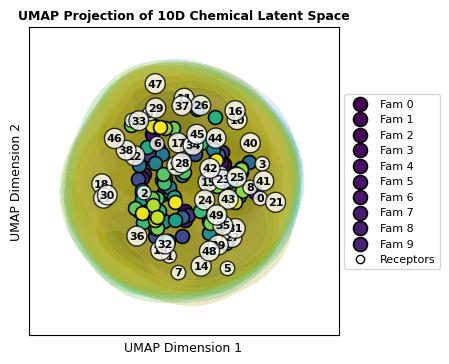

In [9]:
# Plot the latent space visualization for each experiment
fig, ax = plot_latent_umap(env, CONF['receptor_indices'])

(<Figure size 400x300 with 3 Axes>,
 (<Axes: title={'center': 'Global Receptor Array Binary Response'}, ylabel='Activity Probability $p(a=1)$'>,
  <Axes: xlabel='Concentration (M)', ylabel='p(c)'>,
  <Axes: xlabel='Global Mass'>))

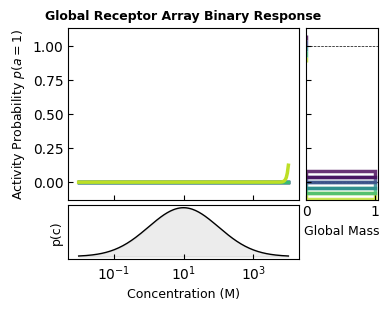

In [25]:
plot_summary(env,rec,CONF['receptor_indices'],loss_fn=loss_fn)